# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.


## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables


Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [64]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [65]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    # Bx28x28
    unfold = nn.Unfold(kernel_size=(patch_size), stride=patch_size)
    return unfold(x).transpose(1, 2)

In [66]:
a = torch.arange(0,784,dtype=float)
b = torch.reshape(a, (1, 1, 28,28))
print(b.shape)

unfold = nn.Unfold(kernel_size=(4), stride=4)

print(unfold(b).transpose(1,2))



torch.Size([1, 1, 28, 28])
tensor([[[  0.,   1.,   2.,   3.,  28.,  29.,  30.,  31.,  56.,  57.,  58.,
           59.,  84.,  85.,  86.,  87.],
         [  4.,   5.,   6.,   7.,  32.,  33.,  34.,  35.,  60.,  61.,  62.,
           63.,  88.,  89.,  90.,  91.],
         [  8.,   9.,  10.,  11.,  36.,  37.,  38.,  39.,  64.,  65.,  66.,
           67.,  92.,  93.,  94.,  95.],
         [ 12.,  13.,  14.,  15.,  40.,  41.,  42.,  43.,  68.,  69.,  70.,
           71.,  96.,  97.,  98.,  99.],
         [ 16.,  17.,  18.,  19.,  44.,  45.,  46.,  47.,  72.,  73.,  74.,
           75., 100., 101., 102., 103.],
         [ 20.,  21.,  22.,  23.,  48.,  49.,  50.,  51.,  76.,  77.,  78.,
           79., 104., 105., 106., 107.],
         [ 24.,  25.,  26.,  27.,  52.,  53.,  54.,  55.,  80.,  81.,  82.,
           83., 108., 109., 110., 111.],
         [112., 113., 114., 115., 140., 141., 142., 143., 168., 169., 170.,
          171., 196., 197., 198., 199.],
         [116., 117., 118., 119., 144

In [67]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(patch_dim, d_model))
        nn.init.normal_(self.weight)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        return x_patches @ self.weight 


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(1, num_tokens, d_model))
        nn.init.normal_(self.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.weight

In [ ]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)


class GLUFeedForward(nn.Module):
    """GLU-family FFN"""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        variant_args = variant.split('_')
        if variant_args[0]=="relu":
            self.act = nn.ReLU()
        elif variant_args[0]=="swish":
            self.act = nn.SiLU()
        elif variant_args[0]=="gelu":
            self.act = nn.GELU()
        else:
            self.act = nn.ReLU()
        
        self.dropout = nn.Dropout(dropout)
        
        self.W = nn.Linear(d_model, d_ff_gated, bias=False)
        self.V = nn.Linear(d_model, d_ff_gated, bias=False)
        self.W2 = nn.Linear(d_ff_gated, d_model, bias=False)       

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        hidden = self.act(self.W(x)) * self.V(x)

        return self.W2(self.dropout(hidden))

In [69]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model, bias = True)
        self.ln2 = nn.LayerNorm(d_model, bias = True)
        self.mlp = mlp

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        normalized_x = self.ln1(x)
        x = x + self.dropout(self.attn(normalized_x, normalized_x, normalized_x)[0])
        x = x + self.dropout(self.mlp(self.ln2(x)))
        return x

In [80]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        # TODO: implement a strategy for embedding the patches
        self.embedding = PatchEmbed(patch_dim, d_model)
        self.pos_emb = PositionalEmbedding(self.num_tokens, d_model)

        # TODO: implement a strategy to select the right mlp version for your experiment
        def ffn_builder():
            d_ff_gated = int(d_ff*(2/3))
            if mlp_kind == "FFN":
                return FeedForward(d_model, d_model * 4, dropout)
            elif mlp_kind == "ReGLU":
                return GLUFeedForward(d_model, d_ff_gated, dropout, "relu")
            elif mlp_kind == "GeGLU":
                return GLUFeedForward(d_model, d_ff_gated, dropout, "gelu")
            elif mlp_kind == "SwiGLU":
                return GLUFeedForward(d_model, d_ff_gated, dropout, "swish")

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=ffn_builder(), # TODO: Feed your mlp to the encoder blocks
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # TODO: Add a head to project to the amount of output classes you have
        self.head = nn.Linear(d_model, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = patchify(x, self.patch_size)
        x = self.embedding(x)
        x = x + self.pos_emb(x)

        for block in self.blocks:
            x = block(x)

        # mean pooling
        x = x.mean(dim=1)
        logits = self.head(x)

        return logits

In [71]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cpu"  # set "cuda" if available

In [ ]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []
    

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = nn.functional.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        "train_losses": train_losses,
        "test_accs": test_accs,
    }

In [81]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = ['FFN', 'ReGLU', 'GeGLU', 'SwiGLU'] # TODO: Name your runs
results = {}
param_counts = {}

for kind in runs:
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    # TODO: print anything you might want here
    print(f"\nRun: {kind} | " )
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    final_acc = out["test_accs"][-1]
    best_acc = max(out["test_accs"])
    print(f"[{kind}] Final Test Acc: {final_acc:.4f} | Best Test Acc: {best_acc:.4f}")

    results[kind] = out
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    param_counts[kind] = num_params


Run: FFN | 
[FFN] epoch 1/5 | test acc: 0.8503
[FFN] epoch 2/5 | test acc: 0.9086
[FFN] epoch 3/5 | test acc: 0.9258
[FFN] epoch 4/5 | test acc: 0.9379
[FFN] epoch 5/5 | test acc: 0.9421
[FFN] Final Test Acc: 0.9421 | Best Test Acc: 0.9421

Run: ReGLU | 
[ReGLU] epoch 1/5 | test acc: 0.8608
[ReGLU] epoch 2/5 | test acc: 0.9147
[ReGLU] epoch 3/5 | test acc: 0.9314
[ReGLU] epoch 4/5 | test acc: 0.9418
[ReGLU] epoch 5/5 | test acc: 0.9504
[ReGLU] Final Test Acc: 0.9504 | Best Test Acc: 0.9504

Run: GeGLU | 
[GeGLU] epoch 1/5 | test acc: 0.8836
[GeGLU] epoch 2/5 | test acc: 0.9227
[GeGLU] epoch 3/5 | test acc: 0.9416
[GeGLU] epoch 4/5 | test acc: 0.9513
[GeGLU] epoch 5/5 | test acc: 0.9563
[GeGLU] Final Test Acc: 0.9563 | Best Test Acc: 0.9563

Run: SwiGLU | 
[SwiGLU] epoch 1/5 | test acc: 0.8903
[SwiGLU] epoch 2/5 | test acc: 0.9293
[SwiGLU] epoch 3/5 | test acc: 0.9420
[SwiGLU] epoch 4/5 | test acc: 0.9532
[SwiGLU] epoch 5/5 | test acc: 0.9595
[SwiGLU] Final Test Acc: 0.9595 | Best Test

Task:
GLU-family (justify choice)
Evaluate whether variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

Metric that is sufficient to support conclusion

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

I have choosen the SwiGLU and ReGLU variants because in the paper by Shazeer, these variants showed the best performance on the NLP fine-tuning GLUE language understanding benchmark. Moreover, I also added the GeGLU variant because it showed the lowest perplexity on the heldout-set on a segment-filling task. Now, it is arguable whether better performing variants on language modeling task automatically lead to better performance on the MNIST classification task. This will be the insight of the experiments of this excercise.
<br>


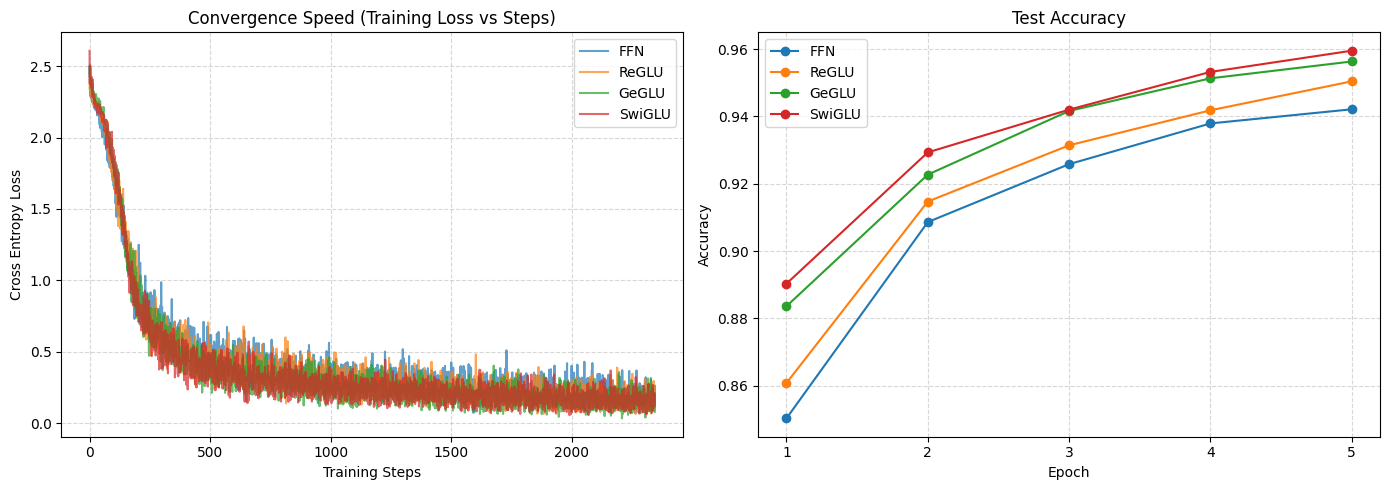


=== Parameter Count Summary ===
     FFN-Variant: 104,778 trainable parameters
   ReGLU-Variant: 103,882 trainable parameters
   GeGLU-Variant: 103,882 trainable parameters
  SwiGLU-Variant: 103,882 trainable parameters



In [84]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convergence Speed (Loss vs. Steps)
for kind in runs:
    ax1.plot(results[kind]["train_losses"], label=kind, alpha=0.7)

ax1.set_title("Convergence Speed (Training Loss vs Steps)")
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Test Accuracy vs Epochs
epochs_range = range(1, cfg.epochs + 1)
for kind in runs:
    ax2.plot(epochs_range, results[kind]["test_accs"], marker='o', label=kind)

ax2.set_title("Test Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_xticks(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n=== Parameter Count Summary ===")
for kind, count in param_counts.items():
    # The :>8 aligns the names, and :, adds formatting commas to the numbers
    print(f"{kind:>8}-Variant: {count:,} trainable parameters")
print(f"===============================\n")


We can see that the SwiGLU variant is the best-performing variant. This reproduces the results of the original paper, where the SwiGLU variant was also always the best variant.

## Dropout Ablation Experiment

Shazeer uses no dropout during pre-training. Therefore, this ablation is run with no dropout to see whether there is an increase in performance for the MNIST classification task with the TinyVIT.


In [85]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
# No Dropout
dropout = 0

runs = ['FFN', 'ReGLU', 'GeGLU', 'SwiGLU'] # TODO: Name your runs
results = {}
param_counts = {}

print("No Dropout Ablation Experiment")

for kind in runs:
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    # TODO: print anything you might want here
    print(f"\nRun: {kind} | " )
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    final_acc = out["test_accs"][-1]
    best_acc = max(out["test_accs"])
    print(f"[{kind}] Final Test Acc: {final_acc:.4f} | Best Test Acc: {best_acc:.4f}")

    results[kind] = out
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    param_counts[kind] = num_params

No Dropout Ablation Experiment

Run: FFN | 
[FFN] epoch 1/5 | test acc: 0.8644
[FFN] epoch 2/5 | test acc: 0.9120
[FFN] epoch 3/5 | test acc: 0.9275
[FFN] epoch 4/5 | test acc: 0.9363
[FFN] epoch 5/5 | test acc: 0.9451
[FFN] Final Test Acc: 0.9451 | Best Test Acc: 0.9451

Run: ReGLU | 
[ReGLU] epoch 1/5 | test acc: 0.8758
[ReGLU] epoch 2/5 | test acc: 0.9204
[ReGLU] epoch 3/5 | test acc: 0.9399
[ReGLU] epoch 4/5 | test acc: 0.9439
[ReGLU] epoch 5/5 | test acc: 0.9543
[ReGLU] Final Test Acc: 0.9543 | Best Test Acc: 0.9543

Run: GeGLU | 
[GeGLU] epoch 1/5 | test acc: 0.8792
[GeGLU] epoch 2/5 | test acc: 0.9155
[GeGLU] epoch 3/5 | test acc: 0.9309
[GeGLU] epoch 4/5 | test acc: 0.9464
[GeGLU] epoch 5/5 | test acc: 0.9492
[GeGLU] Final Test Acc: 0.9492 | Best Test Acc: 0.9492

Run: SwiGLU | 
[SwiGLU] epoch 1/5 | test acc: 0.8891
[SwiGLU] epoch 2/5 | test acc: 0.9284
[SwiGLU] epoch 3/5 | test acc: 0.9416
[SwiGLU] epoch 4/5 | test acc: 0.9540
[SwiGLU] epoch 5/5 | test acc: 0.9587
[SwiGLU] Fin

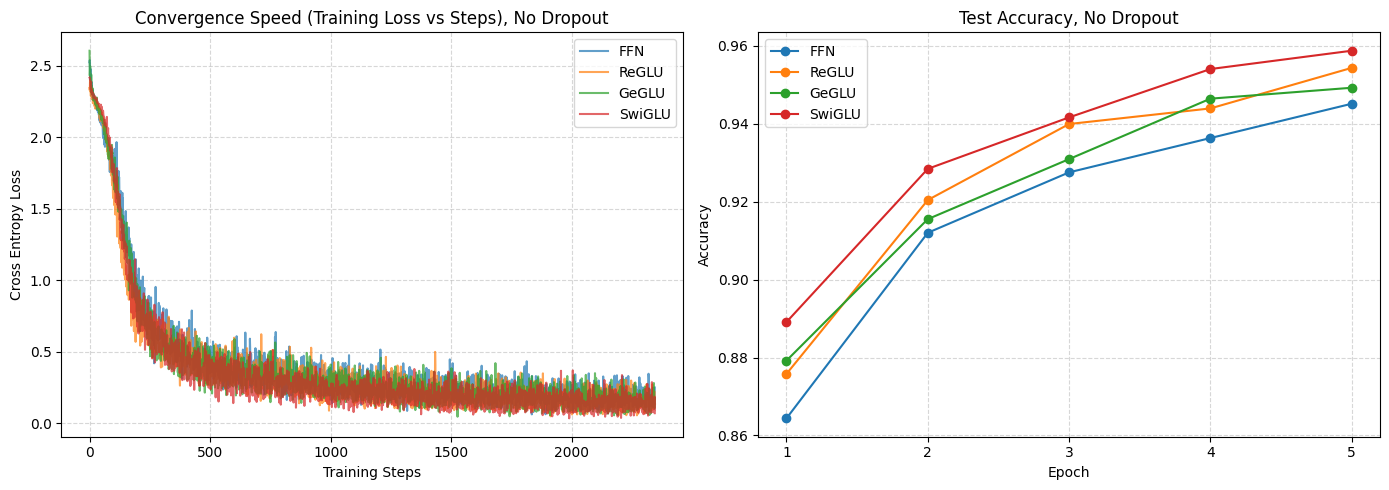

In [86]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convergence Speed (Loss vs. Steps)
for kind in runs:
    ax1.plot(results[kind]["train_losses"], label=kind, alpha=0.7)

ax1.set_title("Convergence Speed (Training Loss vs Steps), No Dropout")
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Test Accuracy vs Epochs
epochs_range = range(1, cfg.epochs + 1)
for kind in runs:
    ax2.plot(epochs_range, results[kind]["test_accs"], marker='o', label=kind)

ax2.set_title("Test Accuracy, No Dropout")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_xticks(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [89]:
results_iter = []
for i in range(4):
    cfg = TrainConfig(seed=i, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

    tfm = transforms.Compose([transforms.ToTensor()])

    train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
    test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

    # Tiny model example. TODO: You're welcome to experiment with these parameters
    patch_size = 4
    d_model = 64
    n_heads = 4
    n_layers = 2
    d_ff = 256
    dropout = 0.1

    runs = ['FFN', 'ReGLU', 'GeGLU', 'SwiGLU'] # TODO: Name your runs
    results = {}
    param_counts = {}

    for kind in runs:
        model = TinyViT(
            patch_size=patch_size,
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            d_ff=d_ff,
            dropout=dropout,
            mlp_kind=kind,
        )
        # TODO: print anything you might want here
        print(f"\nRun: {kind} | " )
        out = train_one_run(kind, model, train_loader, test_loader, cfg)
        final_acc = out["test_accs"][-1]
        best_acc = max(out["test_accs"])
        print(f"[{kind}] Final Test Acc: {final_acc:.4f} | Best Test Acc: {best_acc:.4f}")

        results[kind] = out
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        param_counts[kind] = num_params

    results_iter.append(results)


Run: FFN | 
[FFN] epoch 1/5 | test acc: 0.8419
[FFN] epoch 2/5 | test acc: 0.9015
[FFN] epoch 3/5 | test acc: 0.9170
[FFN] epoch 4/5 | test acc: 0.9302
[FFN] epoch 5/5 | test acc: 0.9356
[FFN] Final Test Acc: 0.9356 | Best Test Acc: 0.9356

Run: ReGLU | 
[ReGLU] epoch 1/5 | test acc: 0.8735
[ReGLU] epoch 2/5 | test acc: 0.9242
[ReGLU] epoch 3/5 | test acc: 0.9424
[ReGLU] epoch 4/5 | test acc: 0.9491
[ReGLU] epoch 5/5 | test acc: 0.9574
[ReGLU] Final Test Acc: 0.9574 | Best Test Acc: 0.9574

Run: GeGLU | 
[GeGLU] epoch 1/5 | test acc: 0.8656
[GeGLU] epoch 2/5 | test acc: 0.9196
[GeGLU] epoch 3/5 | test acc: 0.9391
[GeGLU] epoch 4/5 | test acc: 0.9464
[GeGLU] epoch 5/5 | test acc: 0.9534
[GeGLU] Final Test Acc: 0.9534 | Best Test Acc: 0.9534

Run: SwiGLU | 
[SwiGLU] epoch 1/5 | test acc: 0.8665
[SwiGLU] epoch 2/5 | test acc: 0.9192
[SwiGLU] epoch 3/5 | test acc: 0.9341
[SwiGLU] epoch 4/5 | test acc: 0.9436
[SwiGLU] epoch 5/5 | test acc: 0.9504
[SwiGLU] Final Test Acc: 0.9504 | Best Test